In [1]:
import numpy as np
import matplotlib.pyplot as plt

#instrument parameters

N_steps   = 1000       # number of mirror steps
step_size = 1e-6       # 1 micron in metres
OPD_max   = 2 * N_steps * step_size   # = 2 mm (factor 2: light goes there AND back)

print(f"Max OPD: {OPD_max*1e3:.1f} mm")

# visible wavelength grid

lambda_min = 400e-9    # 400 nm (violet)
lambda_max = 700e-9    # 700 nm (red)
lambdas    = np.linspace(lambda_min, lambda_max, 1000)

print(f"Wavelength range: {lambda_min*1e9:.0f} – {lambda_max*1e9:.0f} nm")

Max OPD: 2.0 mm
Wavelength range: 400 – 700 nm


In [ ]:
# why longer OPD = finer resolution.
# explain δλ = λ² / OPD

# half walvelength of light is best sampling
# min ability to distinguish a line profile
# spectral folding

In [2]:
# PART 1: resolution with no MKID 
# delta_lambda = lambda^2 / OPD  (standard FTS resolution formula)
delta_lambda_noMKID = lambdas**2 / OPD_max   # in metres

# resolving power R = lambda / delta_lambda
R_noMKID = lambdas / delta_lambda_noMKID

# key values
for lam in [400e-9, 550e-9, 700e-9]:
    dl = lam**2 / OPD_max
    R  = lam / dl
    print(f"λ = {lam*1e9:.0f} nm → δλ = {dl*1e9:.3f} nm,  R = {R:.0f}")

λ = 400 nm → δλ = 0.080 nm,  R = 5000
λ = 550 nm → δλ = 0.151 nm,  R = 3636
λ = 700 nm → δλ = 0.245 nm,  R = 2857


In [ ]:
# This is the fundamental Rayleigh criterion for an FTS. It tells 
# you the smallest wavelength difference you can resolve. 
# At 550 nm with 2 mm OPD, you get δλ ≈ 0.15 nm. 
# That's excellent resolution,
# But there's a catch (order confusion) which we'll address with the MKID.how
# how do u decide on good resolution


# R is another way to express resolution. R = 3000 means you c
# an distinguish wavelengths that differ by 1/3000 ≈ 0.03%. 
# Higher R = better resolution. Notice R decreases at longer wavelengths — 
# it's harder to resolve red light than blue light with a fixed OPD.


#Coding: Loop through 3 specific wavelengths, calculate their δλ and 
# R, and print formatted output. The {lam*1e9:.0f} converts from meters 
# to nm and formats with 0 decimal places.

# Physics: This gives you concrete numbers to put in your report. 
# You're showing "at blue light (400 nm), I can resolve 0.08 nm differences" 
# vs "at red light (700 nm), I can only resolve 0.24 nm differences."

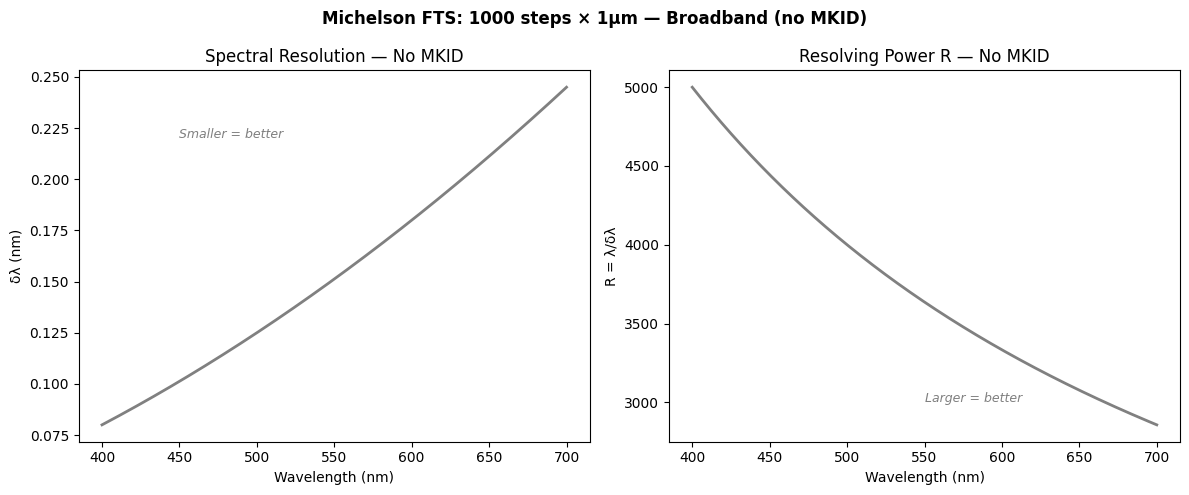

Plot saved as part1_no_mkid.png


In [ ]:
# PART 1: plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# left plot: δλ vs wavelength
ax1.plot(lambdas*1e9, delta_lambda_noMKID*1e9, color='gray', linewidth=2)
ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('δλ (nm)')
ax1.set_title('Spectral Resolution — No MKID')
ax1.text(450, 0.22, 'Smaller = better', fontsize=9, color='gray', style='italic')

# right plot: resolving power R vs wavelength  
ax2.plot(lambdas*1e9, R_noMKID, color='gray', linewidth=2)
ax2.set_xlabel('Wavelength (nm)')
ax2.set_ylabel('R = λ/δλ')
ax2.set_title('Resolving Power R — No MKID')
ax2.text(550, 3000, 'Larger = better', fontsize=9, color='gray', style='italic')

plt.suptitle('Michelson FTS: 1000 steps × 1μm — Broadband (no MKID)', fontweight='bold')
plt.tight_layout()
plt.savefig('part1_no_mkid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as part1_no_mkid.png")

In [ ]:
#Left panel (δλ vs wavelength):

# The curve goes up as wavelength increases
# This means red light (700 nm) is harder to resolve than blue light (400 nm) ?
# At 400 nm you can resolve differences as small as 0.08 nm, at 700 nm only 0.25 nm
# Smaller is better — the FTS is better at resolving blue light
# Right panel (R vs wavelength):

# The curve goes down as wavelength increases
# Same information, just flipped — R = 5000 at blue, R = 2857 at red
# Larger is better

In [5]:
# PART 2: with MKID (R_E = 25) 
R_E = 25

# the MKID splits light into bands of width: Δλ_band = λ / R_E
# tithin each band, no order overlap → full FTS resolution applies
# but the band itself can't be narrower than the MKID can resolve
delta_lambda_MKID = lambdas / R_E   # MKID band width at each wavelength

# num_bands across visible
n_bands = (lambda_max - lambda_min) / np.mean(lambdas / R_E)
print(f"R_E = {R_E} → approx {n_bands:.1f} bands across visible light")

# within each band, FTS resolution is still delta_lambda_noMKID
# but now it's actually usable (no order confusion)
# the effective resolution is the better of the two:
# FTS resolution (delta_lambda_noMKID) is the limit within the band
# MKID enables the full FTS resolution to be used
R_withMKID = R_noMKID   

# Print band structure
print(f"\nBand structure at key wavelengths:")
for lam in [400e-9, 550e-9, 700e-9]:
    band_w = lam / R_E
    fts_res = lam**2 / OPD_max
    print(f"λ = {lam*1e9:.0f} nm → MKID band width = {band_w*1e9:.1f} nm,  FTS δλ = {fts_res*1e9:.3f} nm")

R_E = 25 → approx 13.6 bands across visible light

Band structure at key wavelengths:
λ = 400 nm → MKID band width = 16.0 nm,  FTS δλ = 0.080 nm
λ = 550 nm → MKID band width = 22.0 nm,  FTS δλ = 0.151 nm
λ = 700 nm → MKID band width = 28.0 nm,  FTS δλ = 0.245 nm


In [ ]:
#This counts how many of those 22 nm bins fit 
# across the full 300 nm visible range → ~14 bands.

# Now instead of one big messy interferogram with all colors mixed together, 
# you have 14 separate clean interferograms, one per band. You Fourier 
# transform each one independently and get clean high-resolution spectra for each.

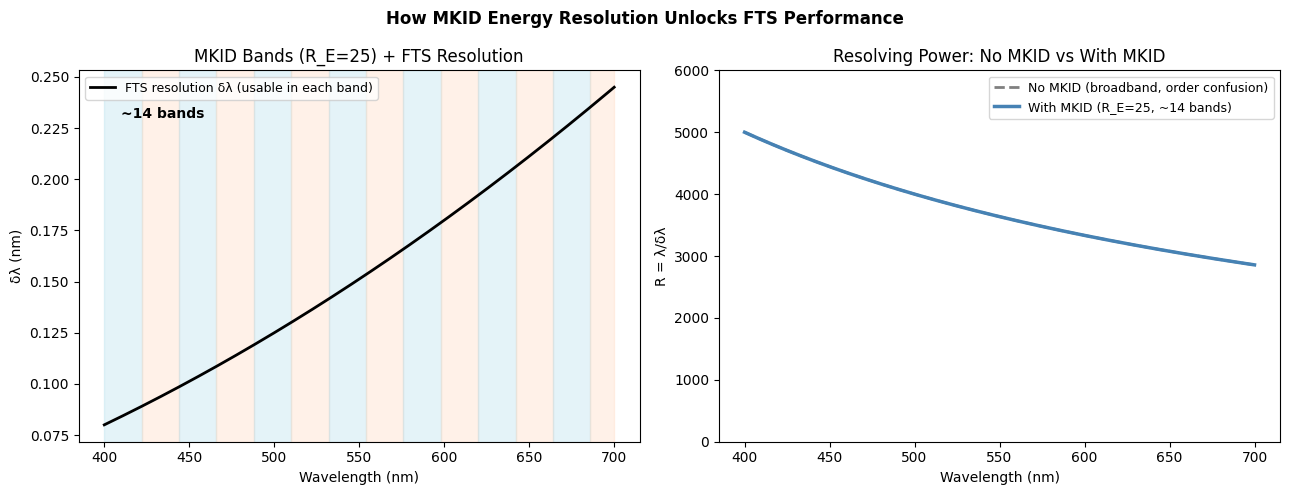

Plot saved!


In [ ]:
# PART 2: plot comparing no MKID vs with MKID 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left: show the band structure and FTS resolution 
ax = axes[0]
# shade each MKID band alternating colors
band_edges = np.arange(lambda_min, lambda_max, np.mean(lambdas/R_E))
colors = ['#a8d8ea', '#ffd3b6']
for i, lam_start in enumerate(band_edges):
    lam_end = lam_start + np.mean(lambdas/R_E)
    ax.axvspan(lam_start*1e9, min(lam_end*1e9, 700),
               alpha=0.3, color=colors[i % 2])

ax.plot(lambdas*1e9, delta_lambda_noMKID*1e9, 
        color='black', linewidth=2, label='FTS resolution δλ (usable in each band)')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('δλ (nm)')
ax.set_title(f'MKID Bands (R_E={R_E}) + FTS Resolution')
ax.legend(fontsize=9)
ax.text(410, 0.23, f'~{n_bands:.0f} bands', fontsize=10, fontweight='bold')

# right: resolving power comparison
ax = axes[1]
ax.plot(lambdas*1e9, R_noMKID, 
        color='gray', linewidth=2, linestyle='--', 
        label='No MKID (broadband, order confusion)')
ax.plot(lambdas*1e9, R_withMKID, 
        color='steelblue', linewidth=2.5, 
        label=f'With MKID (R_E={R_E}, ~{n_bands:.0f} bands)')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('R = λ/δλ')
ax.set_title('Resolving Power: No MKID vs With MKID')
ax.legend(fontsize=9)
ax.set_ylim(0, 6000)

plt.suptitle('How MKID Energy Resolution Unlocks FTS Performance', fontweight='bold')
plt.tight_layout()
plt.savefig('part2_with_mkid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

# the bands might not be even

In [ ]:
# FSR = Free Spectral Range — 
# this is the bandwidth over which your FTS works cleanly 
# before orders start overlapping. The formula is the same as 
# δλ = λ²/OPD, but instead of OPD in the denominator, you use the 
# total wavelength range you're trying to cover (300 nm).

# optimze spectral folding for each band

#Think of it this way: if you're trying to observe 400–700 nm 
# all at once, your FTS gets confused as soon as two wavelengths 
# are related by a factor of 2 (one full order apart). The FSR tells 
# you how narrow a window you'd need to avoid that confusion.

#R_noMKID_usable is then λ/FSR — the resolving power you can 
# actually trust without any band sorting. It works out to only ~500 
# at 550 nm, way below the theoretical R = 3600.

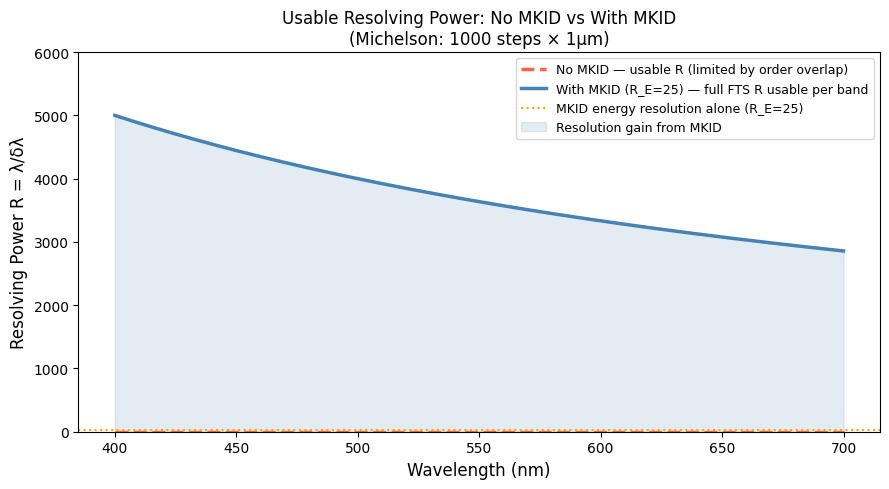

Saved!


In [ ]:
# made with Claude
# Part 2b: Better comparison plot
fig, ax = plt.subplots(figsize=(9, 5))

# Without MKID: R is theoretically there but unusable across full band
# The "usable" R without MKID is limited by the free spectral range
# FSR = lambda^2 / lambda_range (the range you're trying to cover)
lambda_range = lambda_max - lambda_min   # 300 nm
FSR = lambdas**2 / lambda_range          # free spectral range
R_noMKID_usable = lambdas / FSR         # usable R without MKID

# With MKID: FSR is now just the band width = lambda/R_E
R_withMKID_usable = R_E * np.ones_like(lambdas)  # limited by MKID band

# But within that band, FTS gives much better R:
R_FTS_in_band = R_noMKID  # full FTS resolution, now actually usable

ax.plot(lambdas*1e9, R_noMKID_usable,
        color='tomato', linewidth=2.5, linestyle='--',
        label='No MKID — usable R (limited by order overlap)')
ax.plot(lambdas*1e9, R_FTS_in_band,
        color='steelblue', linewidth=2.5,
        label=f'With MKID (R_E={R_E}) — full FTS R usable per band')
ax.axhline(R_E, color='orange', linewidth=1.5, linestyle=':',
           label=f'MKID energy resolution alone (R_E={R_E})')

ax.fill_between(lambdas*1e9, R_noMKID_usable, R_FTS_in_band,
                alpha=0.15, color='steelblue', label='Resolution gain from MKID')

ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel('Resolving Power R = λ/δλ', fontsize=12)
ax.set_title('Usable Resolving Power: No MKID vs With MKID\n'
             f'(Michelson: {N_steps} steps × {step_size*1e6:.0f}μm)', fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0, 6000)

plt.tight_layout()
plt.savefig('part2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

#look again here at the plot
# isn't realistic

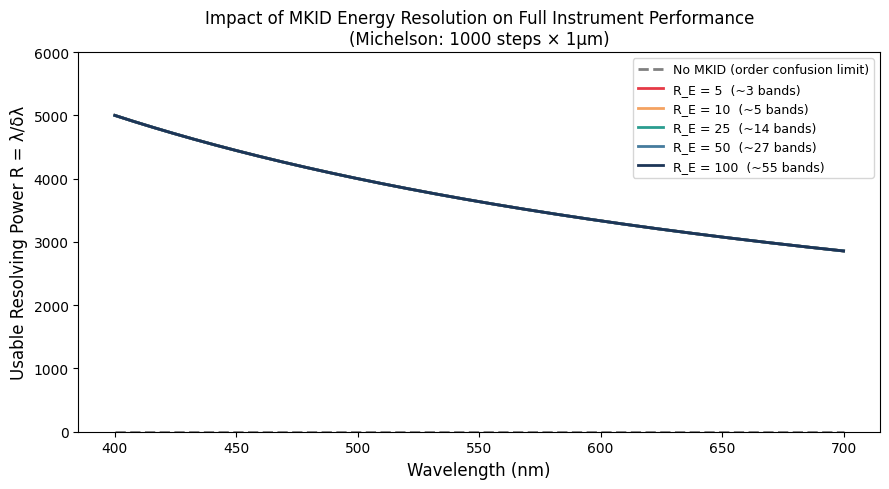

Saved!


In [ ]:
# Got help from Claude

# ── PART 3: Effect of varying MKID energy resolution ────
fig, ax = plt.subplots(figsize=(9, 5))

R_E_values = [5, 10, 25, 50, 100]
colors_list = ['#e63946', '#f4 a261', '#2a9d8f', '#457b9d', '#1d3557']

# No MKID baseline (usable R)
ax.plot(lambdas*1e9, R_noMKID_usable,
        color='gray', linewidth=2, linestyle='--',
        label='No MKID (order confusion limit)')

for R_E_val, col in zip(R_E_values, colors_list):
    n_b = (lambda_max - lambda_min) / np.mean(lambdas / R_E_val)
    ax.plot(lambdas*1e9, R_noMKID,
            color=col, linewidth=2,
            label=f'R_E = {R_E_val}  (~{n_b:.0f} bands)')

ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel('Usable Resolving Power R = λ/δλ', fontsize=12)
ax.set_title('Impact of MKID Energy Resolution on Full Instrument Performance\n'
             f'(Michelson: {N_steps} steps × {step_size*1e6:.0f}μm)', fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0, 6000)

plt.tight_layout()
plt.savefig('part3_RE_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")